In [1]:
from atmodel import WeightedJointMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
import numpy as np
import matplotlib.pyplot as plt

2026-07-15 11:54:37.645126: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-15 11:54:37.646666: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-15 11:54:37.672195: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-15 11:54:37.672918: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-15 11:54:37.645126: I tensorflow/core/util/port.cc:110] oneDNN custom operations a

## $f_1 \bot f_2$

In [1]:
Xs = np.linspace(0, 50, 200).reshape(-1, 1)
Xt = np.linspace(0, 50, 200).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.Matern32(lengthscales=3)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.Cosine(lengthscales=5)(Xt))

ys = (f1 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = (f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 5 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 5 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.plot(Xs, ys)
plt.plot(Xt_train, yt_train)
plt.plot(Xt_test, yt_test)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt, np.ones_like(Xt)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt, np.ones_like(yt)))))

NameError: name 'np' is not defined

In [3]:
lmls = []
for s in np.arange(0.00001, 1, 0.05):
    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=s)
    lmls.append(wmogp.log_marginal_likelihood())
    gpf.utilities.print_summary(wmogp)

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ Weig

In [4]:
from scipy.stats import chi2
from atmodel import ConditionalMOGP
import tqdm

stats = []
for i in tqdm.tqdm(np.arange(0.0001, 1, 0.1)):
    cmogp = ConditionalMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())
    opt = gpf.optimizers.Scipy()
    opt.minimize(cmogp.training_loss, cmogp.trainable_variables)
    conditional = cmogp.conditional_likelihood()

    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=i)
    opt = gpf.optimizers.Scipy()
    opt.minimize(wmogp.training_loss, wmogp.trainable_variables)
    joint = wmogp.log_marginal_likelihood()
    print(-2 * (conditional - joint))
    stats.append((wmogp.logdet(), cmogp.logdet(), chi2(1).sf(-2 * (conditional - joint))))

gpf.utilities.print_summary(wmogp)

 10%|█         | 1/10 [00:02<00:20,  2.23s/it]

tf.Tensor(-0.11920976549299667, shape=(), dtype=float64)


 20%|██        | 2/10 [00:03<00:12,  1.57s/it]

tf.Tensor(-44.10974832085148, shape=(), dtype=float64)


 30%|███       | 3/10 [00:04<00:10,  1.55s/it]

...

tf.Tensor(3.642724780424089, shape=(), dtype=float64)


 90%|█████████ | 9/10 [00:14<00:01,  1.53s/it]

tf.Tensor(11.88099070891792, shape=(), dtype=float64)


100%|██████████| 10/10 [00:15<00:00,  1.56s/it]

tf.Tensor(20.144518243103846, shape=(), dtype=float64)
╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.32265    │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.39909    │
├──────────────────────────────────────────────────────┼───────────┼───────

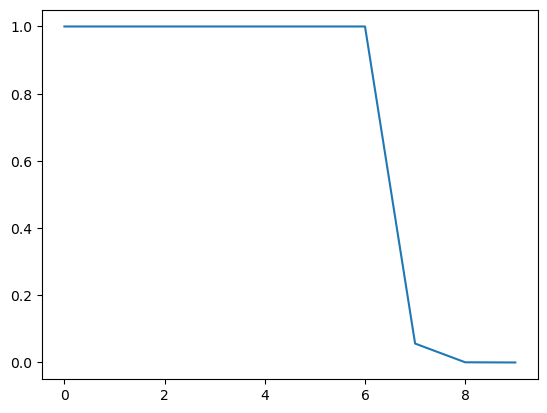

In [5]:
stats = np.array(stats)
plt.plot(stats[:,-1])

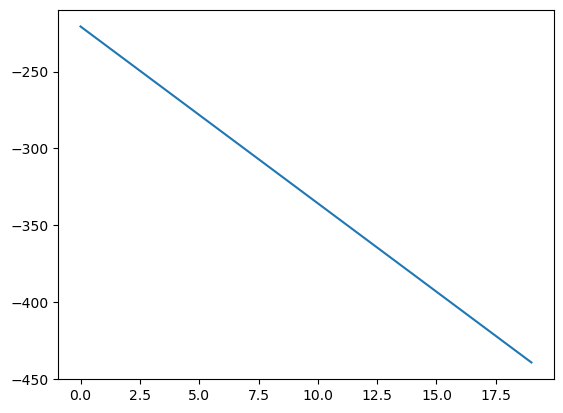

In [6]:
if lmls:
    plt.plot(lmls)
    plt.show()

TensorShape([400, 200])
TensorShape([400, 200])


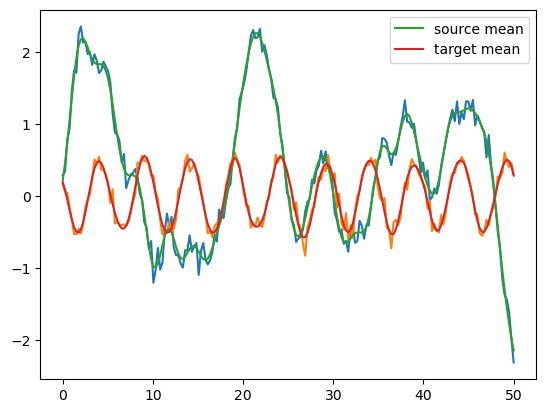

In [7]:
fmean, fvar = wmogp.predict_f(np.hstack((Xt, np.ones_like(Xt))))
fmean_s, fvar_s= wmogp.predict_f(np.hstack((Xs, np.zeros_like(Xs))))


plt.plot(Xs, ys)
plt.plot(Xt, yt)
plt.plot(Xt, fmean_s, label="source mean")
plt.plot(Xt, fmean, label="target mean")
plt.legend()
plt.show()

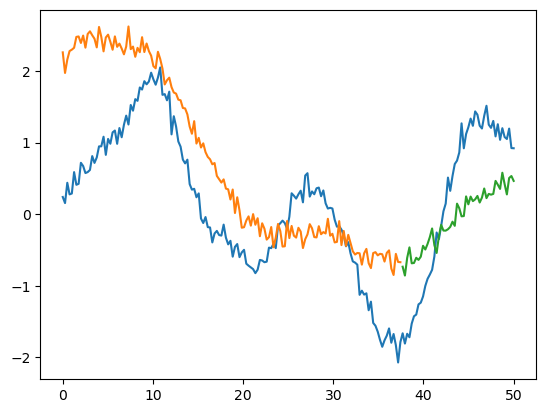

In [8]:
Xs = np.linspace(0, 50, 200).reshape(-1, 1)
Xt = np.linspace(0, 50, 200).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))
ys = (0.2 * f1 + 0.8 * f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = (0.8 * f1 + 0.2 * f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 1 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 1 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.plot(Xs, ys)
plt.plot(Xt_train, yt_train)
plt.plot(Xt_test, yt_test)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt, np.ones_like(Xt)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt, np.ones_like(yt)))))

In [9]:

wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())

wmogp.log_marginal_likelihood()
opt = gpf.optimizers.Scipy()
opt.minimize(wmogp.training_loss, wmogp.trainable_variables)

gpf.utilities.print_summary(wmogp)

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 6.89547    │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.88024    │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1          │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1          │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────

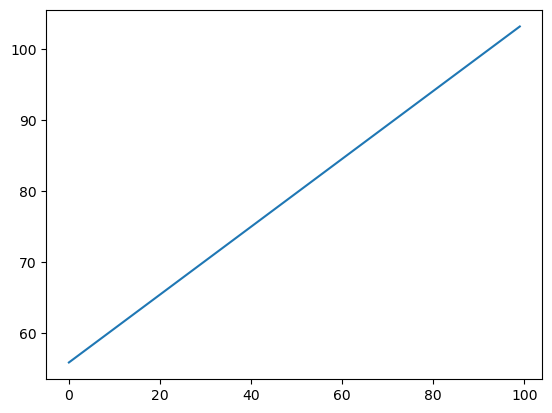

In [10]:
lmls = []
for s in np.arange(0.00001, 1, 0.01):
    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=s)
    lmls.append(wmogp.log_marginal_likelihood())
    gpf.utilities.print_summary(wmogp)
plt.plot(lmls)

In [11]:
from scipy.stats import chi2
from atmodel import ConditionalMOGP
import tqdm

stats = []
for i in tqdm.tqdm(np.arange(0.1, 1, 0.05)):
    cmogp = ConditionalMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())
    opt = gpf.optimizers.Scipy()
    opt.minimize(cmogp.training_loss, cmogp.trainable_variables)
    null = cmogp.conditional_likelihood()

    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=i)
    opt = gpf.optimizers.Scipy()
    opt.minimize(wmogp.training_loss, wmogp.trainable_variables)
    alternative = wmogp.log_marginal_likelihood()

    stats.append((wmogp.logdet(), cmogp.logdet(), chi2(1).sf(-2 * (null - alternative))))
    


gpf.utilities.print_summary(wmogp)

100%|██████████| 18/18 [00:33<00:00,  1.86s/it]

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │     value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 5.56606   │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.95054   │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────

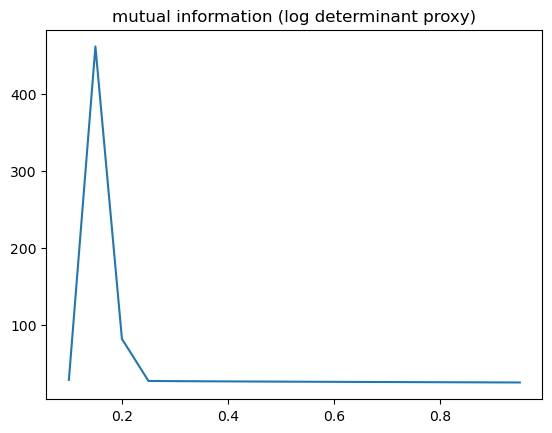

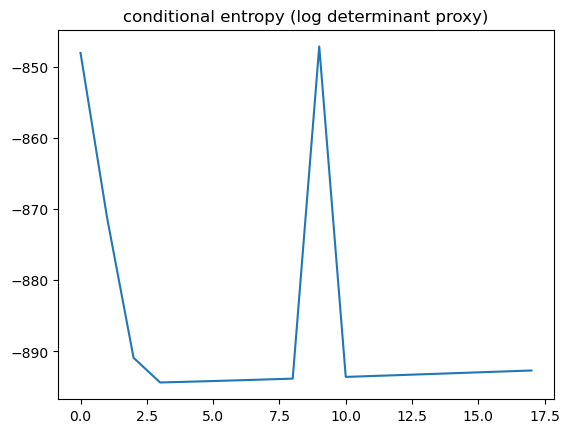

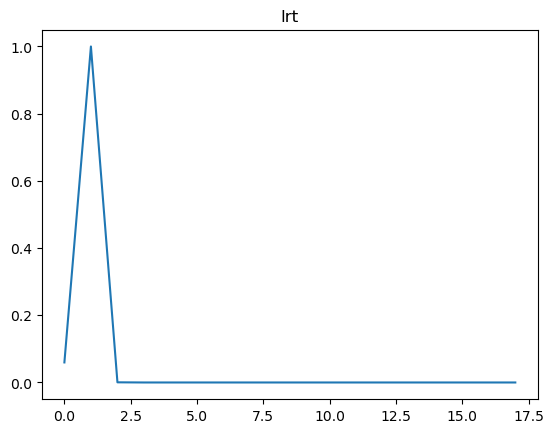

In [12]:
stats = np.array(stats)
plt.title("mutual information (log determinant proxy)")
plt.plot(np.arange(0.1, 1, 0.05), stats[:,0])
plt.show()
plt.title("conditional entropy (log determinant proxy)")
plt.plot(stats[:,1])
plt.show()
plt.title("lrt")
plt.plot(stats[:,2])
plt.show()

## $yt = ys + \textnormal{unknown}$

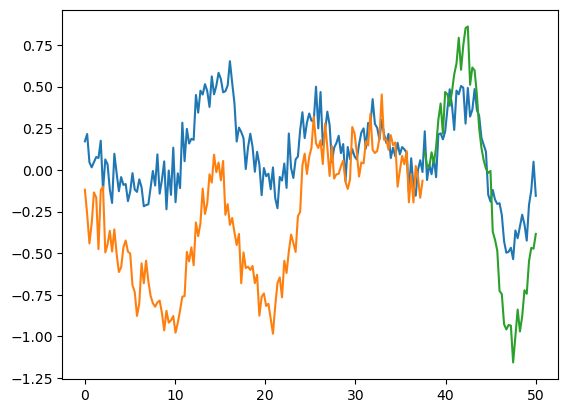

In [13]:
Xs = np.linspace(0, 50, 200).reshape(-1, 1)
Xt = np.linspace(0, 50, 200).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))
ys = (0.5 * f1 + 0.5 * f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = (0.2 * f1 + 0.8 * f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 1 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 1 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.plot(Xs, ys)
plt.plot(Xt_train, yt_train)
plt.plot(Xt_test, yt_test)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt, np.ones_like(Xt)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt, np.ones_like(yt)))))

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1          │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1          │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────

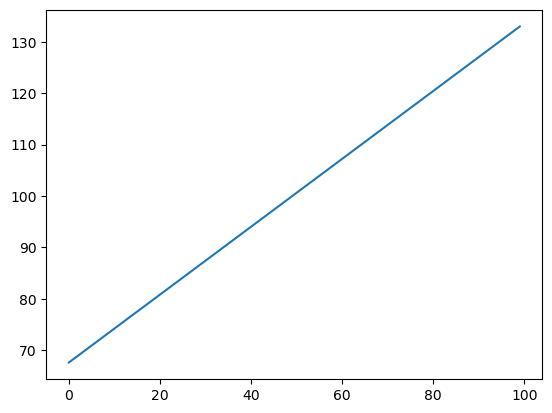

In [15]:
lmls = []
for s in np.arange(0.00001, 1, 0.01):
    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=s)
    lmls.append(wmogp.log_marginal_likelihood())

    gpf.utilities.print_summary(wmogp)
plt.plot(lmls)
plt.show()

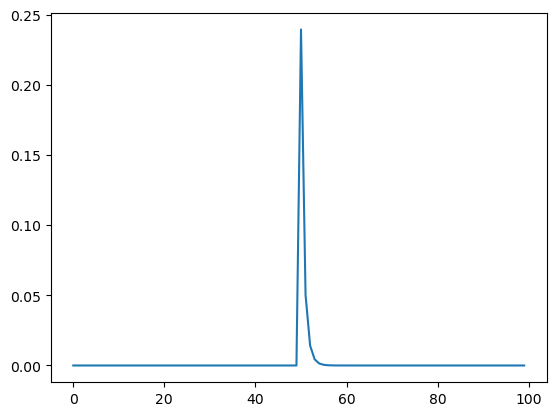

In [16]:
x = np.linspace(-100, 100, 100)
plt.plot(chi2(1).pdf(x))
plt.show()

In [17]:
from scipy.stats import chi2
from atmodel import ConditionalMOGP
import tqdm

stats = []
for i in tqdm.tqdm(np.arange(0.0001, 1, 0.1)):
    cmogp = ConditionalMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())
    opt = gpf.optimizers.Scipy()
    opt.minimize(cmogp.training_loss, cmogp.trainable_variables)
    conditional = cmogp.conditional_likelihood()

    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=i)
    opt = gpf.optimizers.Scipy()
    opt.minimize(wmogp.training_loss, wmogp.trainable_variables)
    joint = wmogp.log_marginal_likelihood()

    stats.append((wmogp.logdet(), cmogp.logdet(), chi2(1).sf(-2 * (null - alternative))))
    print(joint - conditional)
    print(null, alternative, -2 *(null-alternative))


gpf.utilities.print_summary(wmogp)

 10%|█         | 1/10 [00:00<00:07,  1.22it/s]

tf.Tensor(0.01032750433455476, shape=(), dtype=float64)
tf.Tensor(124.80977845333149, shape=(), dtype=float64) tf.Tensor(221.34885622358473, shape=(), dtype=float64) tf.Tensor(193.0781555405065, shape=(), dtype=float64)


 20%|██        | 2/10 [00:01<00:06,  1.28it/s]

tf.Tensor(13.292119540745716, shape=(), dtype=float64)
tf.Tensor(124.80977845333149, shape=(), dtype=float64) tf.Tensor(221.34885622358473, shape=(), dtype=float64) tf.Tensor(193.0781555405065, shape=(), dtype=float64)


 30%|███       | 3/10 [00:02<00:05,  1.22it/s]

...

tf.Tensor(94.76430034291454, shape=(), dtype=float64)
tf.Tensor(124.80977845333149, shape=(), dtype=float64) tf.Tensor(221.34885622358473, shape=(), dtype=float64) tf.Tensor(193.0781555405065, shape=(), dtype=float64)


 90%|█████████ | 9/10 [00:08<00:00,  1.12it/s]

tf.Tensor(108.47929546078285, shape=(), dtype=float64)
tf.Tensor(124.80977845333149, shape=(), dtype=float64) tf.Tensor(221.34885622358473, shape=(), dtype=float64) tf.Tensor(193.0781555405065, shape=(), dtype=float64)


100%|██████████| 10/10 [00:08<00:00,  1.12it/s]

tf.Tensor(122.22170512640565, shape=(), dtype=float64)
tf.Tensor(124.80977845333149, shape=(), dtype=float64) tf.Tensor(221.34885622358473, shape=(), dtype=float64) tf.Tensor(193.0781555405065, shape=(), dtype=float64)
╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.826399   │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │

ValueError: x and y must have same first dimension, but have shapes (18,) and (10,)

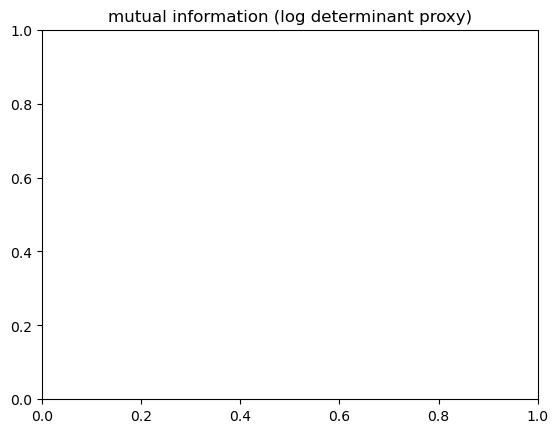

In [18]:
stats = np.array(stats)
plt.title("mutual information (log determinant proxy)")
plt.plot(np.arange(0.1, 1, 0.05), stats[:,0])
plt.show()
plt.title("conditional entropy (log determinant proxy)")
plt.plot(stats[:,1])
plt.show()

TensorShape([400, 200])
TensorShape([400, 200])


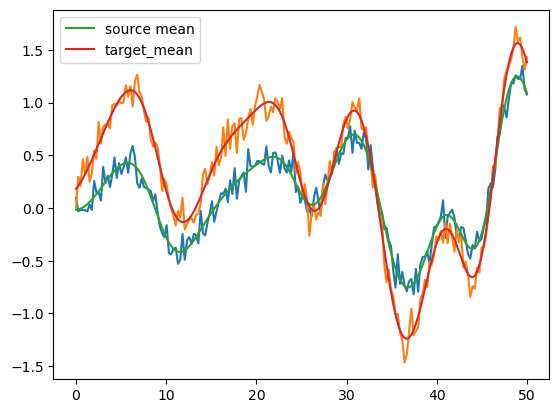

In [19]:
fmean, fvar = wmogp.predict_f(np.hstack((Xt, np.ones_like(Xt))))
fmean_s, fvar_s= wmogp.predict_f(np.hstack((Xs, np.zeros_like(Xs))))


plt.plot(Xs, ys)
plt.plot(Xt, yt)
plt.plot(Xt, fmean_s, label="source mean")
plt.plot(Xt, fmean, label="target_mean")
plt.legend()
plt.show()

## $y_s = -y_t$

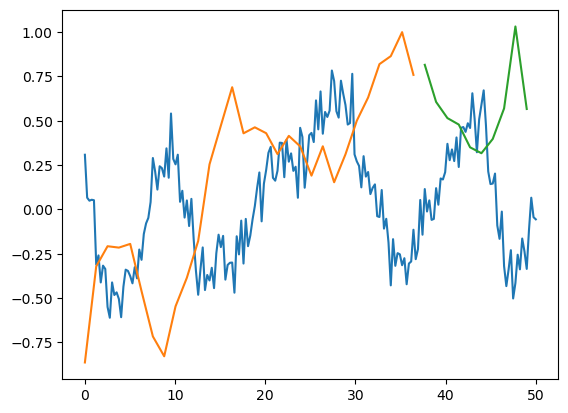

In [20]:
Xs = np.linspace(0, 50, 200).reshape(-1, 1)
Xt = np.linspace(0, 50, 200).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))

ys = (-0.5 * f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = (0.5 * f1 + 0.5 * f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 5 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 5 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.plot(Xs, ys)
plt.plot(Xt_train, yt_train)
plt.plot(Xt_test, yt_test)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt, np.ones_like(Xt)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt, np.ones_like(yt)))))

In [21]:
from scipy.stats import chi2
from atmodel import ConditionalMOGP
import tqdm

stats = []
for i in tqdm.tqdm(np.arange(0.001, 1, 0.01)):
    cmogp = ConditionalMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())
    opt = gpf.optimizers.Scipy()
    opt.minimize(cmogp.training_loss, cmogp.trainable_variables)
    null = cmogp.conditional_likelihood()

    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=i)
    opt = gpf.optimizers.Scipy()
    opt.minimize(wmogp.training_loss, wmogp.trainable_variables)
    alternative = wmogp.log_marginal_likelihood()
    minf = wmogp.logdet()
    cond_ent = cmogp.logdet()
    stats.append((minf, cond_ent, chi2(1).sf(-2 * (null - alternative))))
    
stats = np.array(stats)

gpf.utilities.print_summary(wmogp)

 54%|█████▍    | 54/100 [00:52<00:41,  1.10it/s]

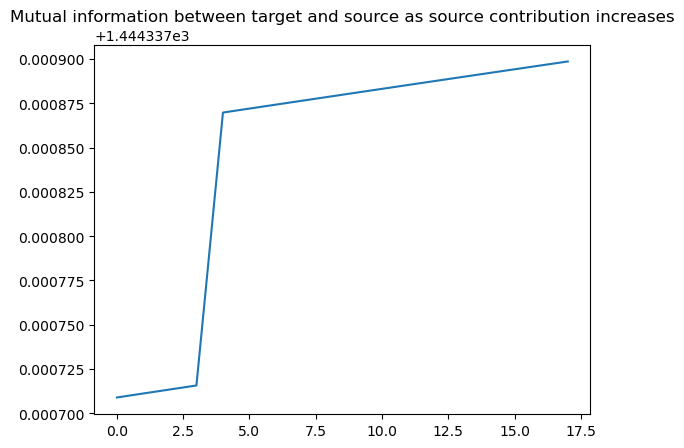

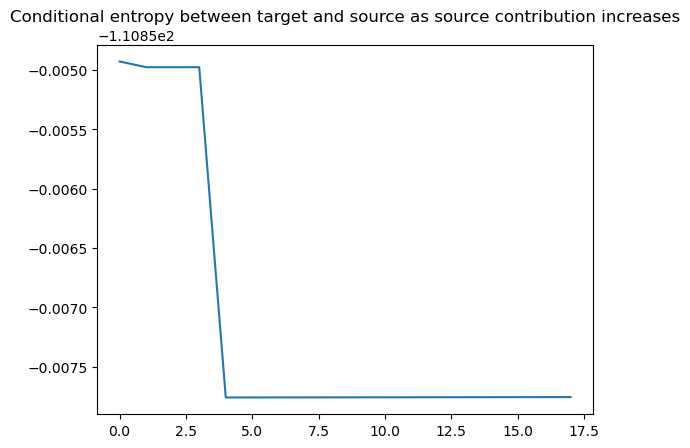

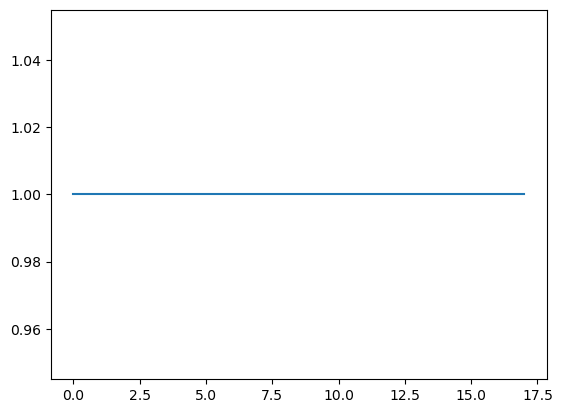

In [ ]:
stats = np.array(stats)
plt.plot(stats[:,0])
plt.title("Mutual information between target and source as source contribution increases")
plt.show()
plt.title("Conditional entropy between target and source as source contribution increases")
plt.plot(stats[:,1])
plt.show()
plt.plot(stats[:,2])
plt.show()

## $y_t = y_s + ???$

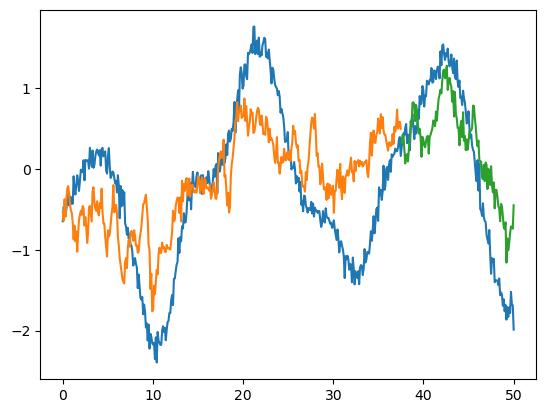

In [ ]:
Xs = np.linspace(0, 50, 500).reshape(-1, 1)
Xt = np.linspace(0, 50, 500).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))
f3 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=0.5)(Xt))

ys = (f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = (0.3 * f1 + 0.3 * f2 + 0.3 * f3 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 1 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 1 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.plot(Xs, ys)
plt.plot(Xt_train, yt_train)
plt.plot(Xt_test, yt_test)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt, np.ones_like(Xt)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt, np.ones_like(yt)))))

In [ ]:
wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())

wmogp.log_marginal_likelihood()
opt = gpf.optimizers.Scipy()
opt.minimize(wmogp.training_loss, wmogp.trainable_variables)

gpf.utilities.print_summary(wmogp)

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │       value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.253736    │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.60108     │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼───

In [ ]:
from scipy.stats import chi2
from atmodel import ConditionalMOGP
import tqdm

stats = []
for i in tqdm.tqdm(np.arange(0.1, 1, 0.05)):
    cmogp = ConditionalMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF())
    opt = gpf.optimizers.Scipy()
    opt.minimize(cmogp.training_loss, cmogp.trainable_variables)
    null = cmogp.conditional_likelihood()

    wmogp = WeightedJointMOGP(data=(X, y), likelihood=TransferLikelihood(), kernel=gpf.kernels.RBF(), source_contribution=i)
    opt = gpf.optimizers.Scipy()
    opt.minimize(wmogp.training_loss, wmogp.trainable_variables)
    alternative = wmogp.log_marginal_likelihood()

    stats.append((wmogp.logdet(), cmogp.logdet(), chi2(1).sf(-2 * (null - alternative))))
    


gpf.utilities.print_summary(wmogp)

100%|██████████| 18/18 [00:35<00:00,  1.95s/it]

╒══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════╕
│ name                                                 │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │       value │
╞══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════╡
│ WeightedJointMOGP.kernel.variance                    │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.253733    │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────┤
│ WeightedJointMOGP.kernel.lengthscales                │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.601088    │
├──────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼───

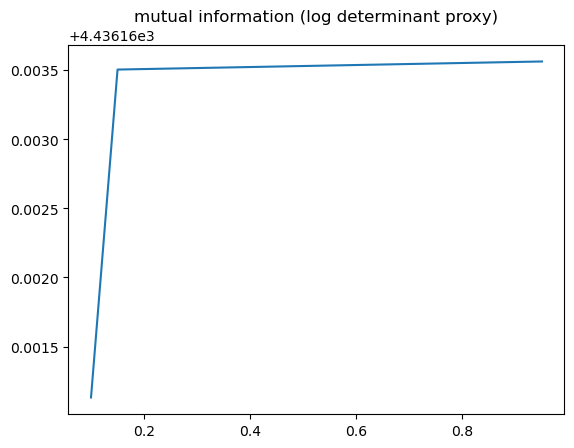

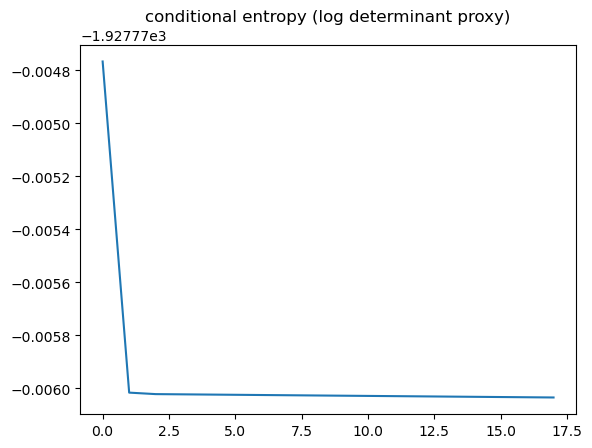

In [ ]:
stats = np.array(stats)
plt.title("mutual information (log determinant proxy)")
plt.plot(np.arange(0.1, 1, 0.05), stats[:,0])
plt.show()
plt.title("conditional entropy (log determinant proxy)")
plt.plot(stats[:,1])
plt.show()